## Linear Regression

> Linear Regression is a statistical method used to model the relationship between a dependent variable and one or more independent variables. It is a type of supervised learning algorithm in machine learning, which is used to predict a continuous outcome variable based on one or more predictor variables.

> The general equation for a linear regression model with one independent variable is:<br>
**y = β<sub>0</sub> + β<sub>1</sub> * x + ε**<br>
where **y** is the dependent variable, **x** is the independent variable, **β<sub>0</sub>** is the intercept term, **β<sub>1</sub>** is the slope coefficient (i.e., the change in **y** per unit change in **x**), and **ε** is the error term (i.e., the part of **y** that is not explained by the linear relationship with **x**).

> The goal of linear regression is to estimate the values of **β<sub>0</sub>** and **β<sub>1</sub>** that minimize the sum of the squared differences between the observed values of **y** and the predicted values of **y** (i.e., the sum of the squared residuals).

> Linear regression models can be used for a variety of applications, such as predicting stock prices, estimating the impact of a marketing campaign, or modeling the relationship between temperature and energy consumption. Linear regression is widely used in both academia and industry because of its simplicity, interpretability, and effectiveness in many real-world situations.

**y' = a + b<sub>1</sub>x<sub>1</sub> + b<sub>2</sub>x<sub>2</sub> + b<sub>3</sub>x<sub>3</sub> + b<sub>4</sub>x<sub>4</sub> + ... + b<sub>n</sub>x<sub>n</sub>**<br>
Where **a** is the intercept<br>
and **x<sub>1</sub>, x<sub>2</sub>, x<sub>3</sub>, x<sub>4</sub>, ... x<sub>n</sub>** are input variables (numeric)<br>
and **b<sub>1</sub>, b<sub>2</sub>, b<sub>3</sub>, b<sub>4</sub>, ... b<sub>n</sub>** are the coefficients<br>
and **y'** is the predicted value<br>
and **n** number variables (numeric)<br>
and **y'** is also numeric output / response variable<br>

In [1]:
# Importing required modules
import warnings
warnings.filterwarnings("ignore")

In [2]:
# !pip install scikit-learn

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import load_boston
# boston = load_boston()
# boston = pd.read_csv("E:\datafile\Boston.csv")
boston = pd.read_csv("https://raw.githubusercontent.com/toarnabtrainer/Secure-Meter-Classwork/refs/heads/main/Datafile/Boston.csv")

In [4]:
print (type(boston), boston.shape)
print (boston.columns)
boston.head()

<class 'pandas.core.frame.DataFrame'> (506, 14)
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'BLACK', 'LSTAT', 'MEDV'],
      dtype='object')


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**1. CRIM -** per capita crime rate by town<br>
**2. ZN -** proportion of residential land zoned for lots over 25,000 sq.ft.<br>
**3. INDUS -** proportion of non-retail business acres per town.<br>
**4. CHAS -** Charles River dummy variable (1 if tract bounds river; 0 otherwise)<br>
**5. NOX -** nitric oxides concentration (parts per 10 million)<br>
**6. RM -** average number of rooms per dwelling<br>
**7. AGE -** proportion of owner-occupied units built prior to 1940<br>
**8. DIS -** weighted distances to five Boston employment centres<br>
**9. RAD -** index of accessibility to radial highways<br>
**10. TAX -** full-value property-tax rate per USD 10,000<br>
**11. PTRATIO -** pupil-teacher ratio by town<br>
**12. B -** 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town<br>
**13. LSTAT -** % lower status of the population<br>
**14. MEDV -** Median value of owner-occupied homes in USD 1000's **(PRICE)**<br>

In [59]:
X = boston.drop('MEDV', axis = 1)
print(X.shape)
X.head()

(506, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [60]:
y = boston.MEDV
print(y.shape)
y

(506,)


0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [61]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
print (type(lm))

<class 'sklearn.linear_model._base.LinearRegression'>


In [62]:
# model training
lm.fit(X, y)

LinearRegression()

In [63]:
print ("Estimated coefficients:", lm.coef_, "and length:", len(lm.coef_))

Estimated coefficients: [-1.08011358e-01  4.64204584e-02  2.05586264e-02  2.68673382e+00
 -1.77666112e+01  3.80986521e+00  6.92224640e-04 -1.47556685e+00
  3.06049479e-01 -1.23345939e-02 -9.52747232e-01  9.31168327e-03
 -5.24758378e-01] and length: 13


In [64]:
print ("Intercept:", lm.intercept_)

Intercept: 36.45948838509


In [65]:
import numpy as np
# test_row has been created from the first row of the dataset with 
# some modifications, whose output PRICE is 24.0
test_row = np.array([0.00632, 17.9, 2.41, 0.0, 0.538, 6.575, 65.5, 4.1000, 1.0, 299.0, 15.4, 396.95, 4.99])
print (test_row, type(test_row))

[6.3200e-03 1.7900e+01 2.4100e+00 0.0000e+00 5.3800e-01 6.5750e+00
 6.5500e+01 4.1000e+00 1.0000e+00 2.9900e+02 1.5400e+01 3.9695e+02
 4.9900e+00] <class 'numpy.ndarray'>


In [66]:
predicted_price = lm.intercept_ + np.sum(lm.coef_ * test_row)
print (predicted_price)

29.849648688217563


In [67]:
predicted_price = lm.predict(boston.drop("MEDV", inplace = False, axis = 1))
print (predicted_price[:5])
print(y[:5])

[30.00384338 25.02556238 30.56759672 28.60703649 27.94352423]
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


In [68]:
print (test_row.reshape(1, -1))
predicted_price = lm.predict(test_row.reshape(1, -1))
print (predicted_price)

[[6.3200e-03 1.7900e+01 2.4100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5500e+01 4.1000e+00 1.0000e+00 2.9900e+02 1.5400e+01 3.9695e+02
  4.9900e+00]]
[29.84964869]


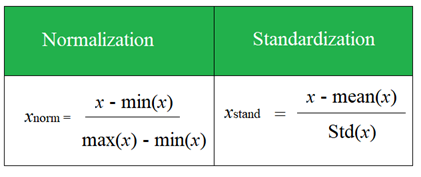

In [69]:
# let us carry out the same linear regression process on X values after scaling
# to improve the performance
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print (X_std)

[[-0.41978194  0.28482986 -1.2879095  ... -1.45900038  0.44105193
  -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 ... -0.30309415  0.44105193
  -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 ... -0.30309415  0.39642699
  -1.2087274 ]
 ...
 [-0.41344658 -0.48772236  0.11573841 ...  1.17646583  0.44105193
  -0.98304761]
 [-0.40776407 -0.48772236  0.11573841 ...  1.17646583  0.4032249
  -0.86530163]
 [-0.41500016 -0.48772236  0.11573841 ...  1.17646583  0.44105193
  -0.66905833]]


In [70]:
def my_fit_transform(X):
    return (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [71]:
X_my_std = my_fit_transform(X)
X_my_std

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.413229,-0.487722,0.115738,-0.272599,0.158124,0.439316,0.018673,-0.625796,-0.982843,-0.803212,1.176466,0.387217,-0.418147
502,-0.415249,-0.487722,0.115738,-0.272599,0.158124,-0.234548,0.288933,-0.716639,-0.982843,-0.803212,1.176466,0.441052,-0.500850
503,-0.413447,-0.487722,0.115738,-0.272599,0.158124,0.984960,0.797449,-0.773684,-0.982843,-0.803212,1.176466,0.441052,-0.983048
504,-0.407764,-0.487722,0.115738,-0.272599,0.158124,0.725672,0.736996,-0.668437,-0.982843,-0.803212,1.176466,0.403225,-0.865302


In [72]:
np.round(X_std) - np.round(X_my_std)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
502,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
503,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
lm.fit(X_std, y)
print ("Estimated coefficients:", lm.coef_, "and length:", len(lm.coef_))
print ("Intercept:", lm.intercept_)

Estimated coefficients: [-0.92814606  1.08156863  0.1409      0.68173972 -2.05671827  2.67423017
  0.01946607 -3.10404426  2.66221764 -2.07678168 -2.06060666  0.84926842
 -3.74362713] and length: 13
Intercept: 22.532806324110677


In [74]:
test_row1 = test_row.reshape(1, -1)
print (test_row1)
test_row_std = scaler.fit_transform(test_row1)
predicted_price = lm.intercept_ + np.sum(lm.coef_ * test_row_std)
print (predicted_price)

[[6.3200e-03 1.7900e+01 2.4100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5500e+01 4.1000e+00 1.0000e+00 2.9900e+02 1.5400e+01 3.9695e+02
  4.9900e+00]]
22.532806324110677


#### Performance Evaluation of Linear Regression Model
> In linear regression, the most commonly used error calculation is the **Mean Squared Error (MSE)**, which measures the average of the squared differences between the predicted and actual values. Here's the formula for calculating the MSE:<br>
**MSE = 1/n * Σ(yi - ŷi)^2**<br><br>
> Another commonly used error calculation is the **Root Mean Squared Error (RMSE)**, which is simply the square root of the MSE. The RMSE is used to measure the average deviation of the predicted values from the actual values, in the same units as the target variable.<br>
**RMSE = sqrt(1/n * Σ(yi - ŷi)^2)**<br><br>
> **Mean Absolute Error (MAE)** is a commonly used evaluation metric in statistics and machine learning, particularly for regression problems. It measures the average absolute difference between the actual and predicted values of a target variable. The formula for calculating MAE is:<br>
**MAE = 1/n * Σ|yi - ŷi|**<br><br>
> **Root Mean Error (RME)** is similar to RMSE (Root Mean Squared Error), which measures the average squared difference between the actual and predicted values. However, RME is less sensitive to outliers than RMSE, since it does not involve squaring the errors. The formula for calculating RME is:<br>
**RME = sqrt(1/n * Σ|yi - ŷi|)**

In [75]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

y_pred = lm.predict(X_std)

# calculate the Mean Squared Error (MSE)
mse_lr = mean_squared_error(y, y_pred)
my_mse_lr = (1/len(y) * np.sum(np.square(y - y_pred)))

# calculate the Root Mean Squared Error (RMSE)
rmse_lr = np.sqrt(mse_lr)
my_rmse_lr = np.sqrt(my_mse_lr)

print (f"Calculated Mean Squared Error (MSE): {mse_lr} and {my_mse_lr}...")
print (f"Calculated Root Mean Squared Error (RMSE): {rmse_lr} and {my_rmse_lr}...")

# calculate the Mean Absolute Error (MAE)
mae_lr = mean_absolute_error(y, y_pred)
my_mae_lr = np.mean(np.abs(y - y_pred))

# calculate the Root Mean Error (RME)
rme_lr = np.sqrt(mae_lr)
my_rme_lr = np.sqrt(my_mae_lr)

print (f"Calculated Mean Absolute Error (MAE): {mae_lr} and {my_mae_lr}...")
print (f"Calculated Root Mean Error (RME): {rme_lr} and {my_rme_lr}...")

Calculated Mean Squared Error (MSE): 21.894831181729206 and 21.894831181729206...
Calculated Root Mean Squared Error (RMSE): 4.679191295697282 and 4.679191295697282...
Calculated Mean Absolute Error (MAE): 3.2708628109003164 and 3.2708628109003164...
Calculated Root Mean Error (RME): 1.8085526840267376 and 1.8085526840267376...


### LASSO regression

#### Lasso stands for Least Absolute Shrinkage and Selection Operator.
* Lasso performs L1 regularization i.e. it adds a factor of sum of absolute value of coefficients in the optimization objectives.
* So objective = RSS + alpha * (sum of absolute value of coefficients)
    * if alpha = 0: same coefficients as simple linear regression 
    * if alpha = infinity: all coefficients will become 0
    * if 0 < alpha < infinity: coefficients between 0 and that for linear regression

> **LASSO (Least Absolute Shrinkage and Selection Operator)** regression is a linear regression technique that adds a regularization term to the loss function. The regularization term adds a penalty to the magnitude of the coefficients, which can help to reduce overfitting and improve the generalization performance of the model.

> LASSO regression is a form of linear regression that adds a regularization term to the objective function of the optimization problem. The objective function of the LASSO regression is to minimize the sum of the squared errors, subject to a constraint on the sum of the absolute values of the coefficients.

> The formula for LASSO regression can be written as:<br>
**minimize: ||y - Xw||^2 + alpha * ||w||_1**<br>
where **y** is the dependent variable, **X** is the independent variable, **w** is the vector of coefficients, **||.||^2** is the L2-norm of the vector, **alpha** is the regularization parameter that controls the strength of the penalty, and **||.||_1** is the **L1-norm** of the vector.

> The **L1-norm** regularization term in LASSO regression has the effect of shrinking some of the coefficients towards zero, which can be seen as a form of feature selection. The result is a sparse model that only includes the most important features for predicting the outcome variable.

> LASSO regression is useful in situations where there are a large number of input variables and many of them may not be important for the prediction task. It is commonly used in machine learning and statistical modeling to reduce the risk of overfitting and improve the accuracy of the model.

In [76]:
# implementing LASSO regression
from sklearn.linear_model import Lasso
regr_lasso = Lasso(alpha = 0.5)

In [77]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print (X_std)

[[-0.41978194  0.28482986 -1.2879095  ... -1.45900038  0.44105193
  -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 ... -0.30309415  0.44105193
  -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 ... -0.30309415  0.39642699
  -1.2087274 ]
 ...
 [-0.41344658 -0.48772236  0.11573841 ...  1.17646583  0.44105193
  -0.98304761]
 [-0.40776407 -0.48772236  0.11573841 ...  1.17646583  0.4032249
  -0.86530163]
 [-0.41500016 -0.48772236  0.11573841 ...  1.17646583  0.44105193
  -0.66905833]]


In [78]:
def my_fit_transform(X):
    return (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [79]:
X_my_std = my_fit_transform(X)
X_my_std

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.413229,-0.487722,0.115738,-0.272599,0.158124,0.439316,0.018673,-0.625796,-0.982843,-0.803212,1.176466,0.387217,-0.418147
502,-0.415249,-0.487722,0.115738,-0.272599,0.158124,-0.234548,0.288933,-0.716639,-0.982843,-0.803212,1.176466,0.441052,-0.500850
503,-0.413447,-0.487722,0.115738,-0.272599,0.158124,0.984960,0.797449,-0.773684,-0.982843,-0.803212,1.176466,0.441052,-0.983048
504,-0.407764,-0.487722,0.115738,-0.272599,0.158124,0.725672,0.736996,-0.668437,-0.982843,-0.803212,1.176466,0.403225,-0.865302


In [80]:
np.round(X_std) - np.round(X_my_std)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
502,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
503,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
lasso_model = regr_lasso.fit(X_std, y)
print ("Estimated coefficients:", lasso_model.coef_, "and length:", len(lasso_model.coef_))
print ("Intercept:", lasso_model.intercept_)

Estimated coefficients: [-0.11526463  0.         -0.          0.39707879 -0.          2.97425861
 -0.         -0.17056942 -0.         -0.         -1.59844856  0.54313871
 -3.66614361] and length: 13
Intercept: 22.532806324110677


In [82]:
test_row1 = test_row.reshape(1, -1)
print (test_row1)
test_row_std = scaler.fit_transform(test_row1) 
predicted_price = lasso_model.intercept_ + np.sum(lasso_model.coef_ * test_row_std)
print (predicted_price)

[[6.3200e-03 1.7900e+01 2.4100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5500e+01 4.1000e+00 1.0000e+00 2.9900e+02 1.5400e+01 3.9695e+02
  4.9900e+00]]
22.532806324110677


In [83]:
predicted_price = lasso_model.predict(test_row_std)
print (predicted_price)

[22.53280632]


#### Performace Evaluation of LASSO Regression Model

In [84]:
y_pred = lasso_model.predict(X_std)

# calculate the Mean Squared Error (MSE)
mse_lasso = mean_squared_error(y, y_pred)
my_mse_lasso = (1/len(y) * np.sum(np.square(y - y_pred)))

# calculate the Root Mean Squared Error (RMSE)
rmse_lasso = np.sqrt(mse_lasso)
my_rmse_lasso = np.sqrt(my_mse_lasso)

print (f"Calculated Mean Squared Error (MSE): {mse_lasso} and {my_mse_lasso}...")
print (f"Calculated Root Mean Squared Error (RMSE): {rmse_lasso} and {my_rmse_lasso}...")

# calculate the Mean Absolute Error (MAE)
mae_lasso = mean_absolute_error(y, y_pred)
my_mae_lasso = np.mean(np.abs(y - y_pred))

# calculate the Root Mean Error (RME)
rme_lasso = np.sqrt(mae_lasso)
my_rme_lasso = np.sqrt(my_mae_lasso)

print (f"Calculated Mean Absolute Error (MAE): {mae_lasso} and {my_mae_lasso}...")
print (f"Calculated Root Mean Error (RME): {rme_lasso} and {my_rme_lasso}...")

Calculated Mean Squared Error (MSE): 26.0556265670908 and 26.055626567090798...
Calculated Root Mean Squared Error (RMSE): 5.10447123285956 and 5.10447123285956...
Calculated Mean Absolute Error (MAE): 3.5234496516803535 and 3.5234496516803535...
Calculated Root Mean Error (RME): 1.877085414060946 and 1.877085414060946...


### RIDGE regression

* **RIDGE Regression** supports 'L2 regularization', i.e. it adds a factor of sum of squares of coefficients in the optimization objectives.
* Objective = RSS + alpha * (Sum of squared coefficients).
* Here alpha is the parameter which balances the amount of emphasis given for minimizing RSS vs minimizing sum of squared coefficients.

> **Ridge regression** is a linear regression technique that adds a regularization term to the loss function. The regularization term adds a penalty to the sum of the squared magnitudes of the coefficients, which can help to reduce overfitting and improve the generalization performance of the model.

> Ridge regression is a form of linear regression that adds a regularization term to the objective function of the optimization problem. The objective function of the Ridge regression is to minimize the sum of the squared errors, subject to a constraint on the sum of the squared magnitudes of the coefficients. The formula for Ridge regression can be written as:<br>
**minimize: ||y - Xw||^2 + alpha * ||w||^2**<br>
where **y** is the dependent variable, **X** is the independent variable, **w** is the vector of coefficients, **||.||^2** is the **L2-norm** of the vector, **alpha** is the regularization parameter that controls the strength of the penalty.

> The L2-norm regularization term in Ridge regression has the effect of shrinking the coefficients towards zero, which can help to reduce the variance of the model and improve its generalization performance. The result is a model that is less likely to overfit the training data and can make more accurate predictions on new, unseen data.

> Ridge regression is commonly used in machine learning and statistical modeling to reduce the risk of overfitting and improve the accuracy of the model.

In [85]:
# implementing RIDGE regression
from sklearn.linear_model import Ridge
regr_ridge = Ridge(alpha = 0.5)

In [86]:
ridge_model = regr_ridge.fit(X_std, y)
print ("Estimated coefficients:", ridge_model.coef_, "and length:", len(ridge_model.coef_))
print ("Intercept:", ridge_model.intercept_)

Estimated coefficients: [-0.92396151  1.07393055  0.12895159  0.68346136 -2.0427575   2.67854971
  0.01627328 -3.09063352  2.62636926 -2.04312573 -2.05646414  0.8490591
 -3.73711409] and length: 13
Intercept: 22.532806324110677


In [87]:
test_row1 = test_row.reshape(1, -1)
print (test_row1)
test_row_std = scaler.fit_transform(test_row1) 
predicted_price = ridge_model.intercept_ + np.sum(ridge_model.coef_ * test_row_std)
print (predicted_price)
predicted_price = ridge_model.predict(test_row_std)[0]
print(predicted_price)

[[6.3200e-03 1.7900e+01 2.4100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5500e+01 4.1000e+00 1.0000e+00 2.9900e+02 1.5400e+01 3.9695e+02
  4.9900e+00]]
22.532806324110677
22.532806324110677


In [88]:
predicted_price = ridge_model.predict(test_row_std)
print (predicted_price)

[22.53280632]


#### Performance Evaluation of Ridge Regression Model

In [89]:
y_pred = ridge_model.predict(X_std)

# calculate the Mean Squared Error (MSE)
mse_ridge = mean_squared_error(y, y_pred)
my_mse_ridge = (1/len(y) * np.sum(np.square(y - y_pred)))

# calculate the Root Mean Squared Error (RMSE)
rmse_ridge = np.sqrt(mse_ridge)
my_rmse_ridge = np.sqrt(my_mse_ridge)

print (f"Calculated Mean Squared Error (MSE): {mse_ridge} and {my_mse_ridge}...")
print (f"Calculated Root Mean Squared Error (RMSE): {rmse_ridge} and {my_rmse_ridge}...")

# calculate the Mean Absolute Error (MAE)
mae_ridge = mean_absolute_error(y, y_pred)
my_mae_ridge = np.mean(np.abs(y - y_pred))

# calculate the Root Mean Error (RME)
rme_ridge = np.sqrt(mae_ridge)
my_rme_ridge = np.sqrt(my_mae_ridge)

print (f"Calculated Mean Absolute Error (MAE): {mae_ridge} and {my_mae_ridge}...")
print (f"Calculated Root Mean Error (RME): {rme_ridge} and {my_rme_ridge}...")

Calculated Mean Squared Error (MSE): 21.89509484997131 and 21.895094849971308...
Calculated Root Mean Squared Error (RMSE): 4.67921947016501 and 4.679219470165009...
Calculated Mean Absolute Error (MAE): 3.269082355412753 and 3.269082355412753...
Calculated Root Mean Error (RME): 1.8080603848911554 and 1.8080603848911554...


#### Performance Comparisons

In [90]:
print (f"In Linear Regression MSE = {mse_lr}, RMSE = {rmse_lr}, MAE = {mae_lr} and RME = {rme_lr}...")
print (f"In LASSO Regression MSE = {mse_lasso}, RMSE = {rmse_lasso}, MAE = {mae_lasso} and RME = {rme_lasso}...")
print (f"In Ridge Regression MSE = {mse_ridge}, RMSE = {rmse_ridge}, MAE = {mae_ridge} and RME = {rme_ridge}...")

In Linear Regression MSE = 21.894831181729206, RMSE = 4.679191295697282, MAE = 3.2708628109003164 and RME = 1.8085526840267376...
In LASSO Regression MSE = 26.0556265670908, RMSE = 5.10447123285956, MAE = 3.5234496516803535 and RME = 1.877085414060946...
In Ridge Regression MSE = 21.89509484997131, RMSE = 4.67921947016501, MAE = 3.269082355412753 and RME = 1.8080603848911554...


In [91]:
import pandas as pd
results = {"MSE":[mse_lr, mse_lasso, mse_ridge], "RMSE":[rmse_lr, rmse_lasso, rmse_ridge], 
           "MAE":[mae_lr, mae_lasso, mae_ridge], "RME":[rme_lr, rme_lasso, rme_ridge]}
evaluation = pd.DataFrame(data = results)
evaluation.index = ["Linear_Regression", "Lasso_Regression", "Ridge_Regression"]
evaluation

,MSE,RMSE,MAE,RME
Linear_Regression,21.894831,4.679191,3.270863,1.808553
Lasso_Regression,26.055627,5.104471,3.523450,1.877085
Ridge_Regression,21.895095,4.679219,3.269082,1.808060
